
TRE STATISTICS (Mean ± Std Dev / Median in mm)

Full Sweep
--------------------------------------------------------------------------------

  Pose 1:
    L1:  No data available
    L2:  No data available
    L3:  No data available
    L4:  No data available

  Pose 2:
    L1:  No data available
    L2:  No data available
    L3:  No data available
    L4:  No data available

  Pose 3:
    L1:  No data available
    L2:  No data available
    L3:  No data available
    L4:  No data available

  OVERALL:  No data available

Slice Sweep
--------------------------------------------------------------------------------

  Pose 1:
    L1:  No data available
    L2:  No data available
    L3:  No data available
    L4:  No data available

  Pose 2:
    L1:  No data available
    L2:  No data available
    L3:  No data available
    L4:  No data available

  Pose 3:
    L1:  No data available
    L2:  No data available
    L3:  No data available
    L4:  No data available

  OVERALL:  No data

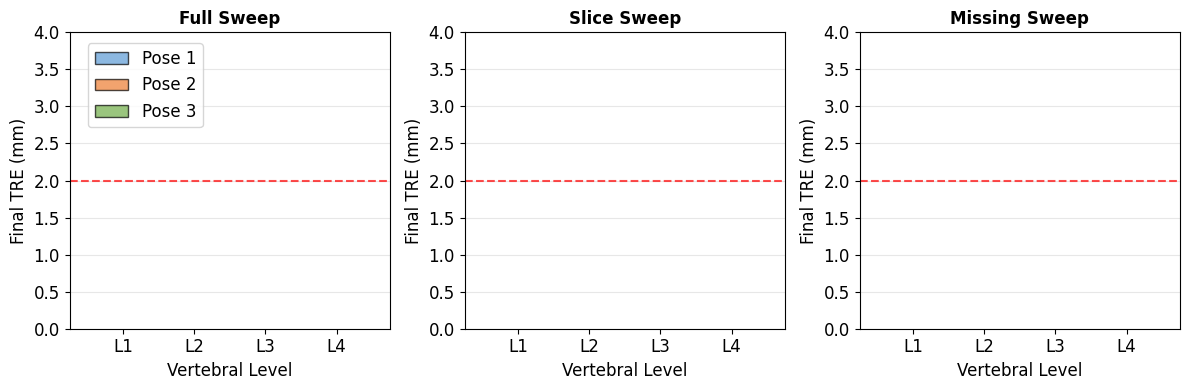

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from pathlib import Path

# Base path - UPDATE THIS to your actual path
BASE_PATH = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/experiments"

# Define the structure
poses = ['sofa1', 'sofa3', 'sofa6']  # Corresponds to Pose 1, 2, 3
conditions = ['full', 'slice', 'missing']
vertebrae = ['L1', 'L2', 'L3', 'L4']

def load_tre_data(filepath):
    """
    Load TRE data from JSON file.
    
    Expected return format:
    {
        'L1': [list of TRE values],
        'L2': [list of TRE values],
        'L3': [list of TRE values],
        'L4': [list of TRE values]
    }
    """
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
        
        tre_by_vertebra = {'L1': [], 'L2': [], 'L3': [], 'L4': []}
        
        # Extract final_tre data from the first (and typically only) entry
        for key in data.keys():
            if key != '_summary' and 'final_tre' in data[key]:
                final_tre_list = data[key]['final_tre']
                
                # Collect TRE values for each vertebra across ALL runs
                for i, tre_dict in enumerate(final_tre_list):
                    for vert in ['L1', 'L2', 'L3', 'L4']:
                        tre_by_vertebra[vert].append(tre_dict[vert])
                
                break  # Assuming one main entry per file
        
        return tre_by_vertebra
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def collect_data():
    """Collect all TRE data organized by condition and initialization type."""
    data = {
        'full_normal': {},           # Panel 1: full/constraints.json
        'slice_normal': {},          # Panel 2: slice/constraints.json
        'missing_normal': {},        # Panel 3: missing/constraints.json
    }
    
    # Initialize data structure for each vertebra and pose
    for panel in data.keys():
        for vert in vertebrae:
            data[panel][vert] = {}
            for pose_idx in range(len(poses)):
                data[panel][vert][f'Pose {pose_idx + 1}'] = []
    
    for pose_idx, pose in enumerate(poses):
        pose_name = f'Pose {pose_idx + 1}'
        
        # Full sweep - normal
        full_normal_path = os.path.join(BASE_PATH, pose, 'full', '30', 'constraints.json')
        if os.path.exists(full_normal_path):
            full_normal_data = load_tre_data(full_normal_path)
            if full_normal_data:
                for vert in vertebrae:
                    if vert in full_normal_data and full_normal_data[vert]:
                        data['full_normal'][vert][pose_name] = full_normal_data[vert]
        else:
            print(f"Warning: File not found: {full_normal_path}")
        
        # Slice sweep - normal
        slice_normal_path = os.path.join(BASE_PATH, pose, 'slice','30', 'constraints.json')
        if os.path.exists(slice_normal_path):
            slice_normal_data = load_tre_data(slice_normal_path)
            if slice_normal_data:
                for vert in vertebrae:
                    if vert in slice_normal_data and slice_normal_data[vert]:
                        data['slice_normal'][vert][pose_name] = slice_normal_data[vert]
        else:
            print(f"Warning: File not found: {slice_normal_path}")
        
        # Missing sweep - normal
        missing_normal_path = os.path.join(BASE_PATH, pose, 'missing','30', 'constraints.json')
        if os.path.exists(missing_normal_path):
            missing_normal_data = load_tre_data(missing_normal_path)
            if missing_normal_data:
                for vert in vertebrae:
                    if vert in missing_normal_data and missing_normal_data[vert]:
                        data['missing_normal'][vert][pose_name] = missing_normal_data[vert]
        else:
            print(f"Warning: File not found: {missing_normal_path}")
    
    return data

def print_statistics(data):
    """Print mean, median, and standard deviation for each condition, pose, and vertebra."""
    print("\n" + "="*80)
    print("TRE STATISTICS (Mean ± Std Dev / Median in mm)")
    print("="*80)
    
    conditions = [
        ('full_normal', 'Full Sweep'),
        ('slice_normal', 'Slice Sweep'),
        ('missing_normal', 'Missing Sweep')
    ]
    
    # Store overall values for summary
    overall_summary = {}
    
    for condition_key, title in conditions:
        print(f"\n{title}")
        print("-" * 80)
        
        # Collect all values for overall statistics
        all_values = []
        
        for pose_idx in range(len(poses)):
            pose_name = f'Pose {pose_idx + 1}'
            print(f"\n  {pose_name}:")
            
            for vert in vertebrae:
                if vert in data[condition_key] and pose_name in data[condition_key][vert]:
                    values = data[condition_key][vert][pose_name]
                    if len(values) > 0:
                        mean_val = np.mean(values)
                        median_val = np.median(values)
                        std_val = np.std(values)
                        n = len(values)
                        print(f"    {vert}:  {mean_val:.3f} ± {std_val:.3f} mm  (median: {median_val:.3f})  (n={n})")
                        all_values.extend(values)
                    else:
                        print(f"    {vert}:  No data available")
                else:
                    print(f"    {vert}:  No data available")
        
        # Print overall statistics for this condition
        if len(all_values) > 0:
            overall_mean = np.mean(all_values)
            overall_median = np.median(all_values)
            overall_std = np.std(all_values)
            overall_n = len(all_values)
            print(f"\n  OVERALL (all poses & vertebrae):  {overall_mean:.3f} ± {overall_std:.3f} mm  (median: {overall_median:.3f})  (n={overall_n})")
            overall_summary[title] = (overall_mean, overall_median, overall_std, overall_n)
        else:
            print(f"\n  OVERALL:  No data available")
            overall_summary[title] = None
    
    # Print summary comparison
    print("\n" + "="*80)
    print("SUMMARY: Overall Mean TRE Across All Levels and Poses")
    print("="*80)
    for title in ['Full Sweep', 'Slice Sweep', 'Missing Sweep']:
        if overall_summary.get(title):
            mean, median, std, n = overall_summary[title]
            print(f"{title:20s}:  {mean:.3f} ± {std:.3f} mm  (median: {median:.3f})  (n={n})")
        else:
            print(f"{title:20s}:  No data available")
    print("="*80 + "\n")

def create_boxplot(ax, data_dict, title, vertebrae_labels):
    """Create a single subplot with box plots."""
    colors = ['#5B9BD5', '#ED7D31', '#70AD47']  # Blue, Orange, Green for Pose 1, 2, 3
    
    positions_base = np.arange(len(vertebrae_labels))
    width = 0.25
    
    all_boxes = []
    
    for pose_idx in range(len(poses)):
        pose_name = f'Pose {pose_idx + 1}'
        positions = positions_base + (pose_idx - 1) * width
        
        # Collect data for each vertebra
        plot_data = []
        for vert in vertebrae_labels:
            if vert in data_dict and pose_name in data_dict[vert]:
                plot_data.append(data_dict[vert][pose_name])
            else:
                plot_data.append([])  # Empty if no data
        
        # Create box plot
        bp = ax.boxplot(plot_data, positions=positions, widths=width*0.8,
                       patch_artist=True, showfliers=True,
                       boxprops=dict(facecolor=colors[pose_idx], alpha=0.7),
                       medianprops=dict(color='black', linewidth=1.5),
                       whiskerprops=dict(color='black'),
                       capprops=dict(color='black'))
        
        all_boxes.append(bp['boxes'][0])
    
    # Add reference line at 2.0 mm
    ax.axhline(y=2.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Formatting
    ax.set_xticks(positions_base)
    ax.set_xticklabels(vertebrae_labels)
    ax.set_xlabel('Vertebral Level', fontsize=12)
    ax.set_ylabel('Final TRE (mm)', fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 4) 
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set tick label font size - ADD THIS LINE
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    return all_boxes

def main():
    # Collect all data
    print("Collecting data...")
    data = collect_data()
    
    # Print statistics
    print_statistics(data)
    
    # Create figure with 1x3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # Plot each condition with normal initialization
    boxes1 = create_boxplot(axes[0], data['full_normal'], 
                           'Full Sweep', vertebrae)
    boxes2 = create_boxplot(axes[1], data['slice_normal'], 
                           'Slice Sweep', vertebrae)
    boxes3 = create_boxplot(axes[2], data['missing_normal'], 
                           'Missing Sweep', vertebrae)
    
    # Add legend
    pose_labels = ['Pose 1', 'Pose 2', 'Pose 3', 'Pose 4']
    colors = ['#5B9BD5', '#ED7D31', '#70AD47']
    legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colors[i], alpha=0.7, 
                                    edgecolor='black', label=pose_labels[i]) 
                      for i in range(3)]
    
    fig.legend(handles=legend_elements, loc='upper right', 
              bbox_to_anchor=(0.18, 0.9), frameon=True, fontsize=12)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


TRE STATISTICS (Mean ± Std Dev / Median in mm)

Full Sweep + Rand Init
--------------------------------------------------------------------------------

  Pose 1:
    With Constraints:    0.848 ± 0.042 mm  (median: 0.849)  (n=30)
    No Constraints:      1.838 ± 1.438 mm  (median: 1.013)  (n=30)

  Pose 2:
    With Constraints:    0.810 ± 0.031 mm  (median: 0.814)  (n=30)
    No Constraints:      1.572 ± 1.372 mm  (median: 1.011)  (n=30)

  Pose 3:
    With Constraints:    0.870 ± 0.038 mm  (median: 0.874)  (n=30)
    No Constraints:      3.190 ± 3.148 mm  (median: 2.506)  (n=30)

  Pose 4:
    With Constraints:    1.379 ± 2.688 mm  (median: 0.881)  (n=30)
    No Constraints:      2.923 ± 3.216 mm  (median: 1.098)  (n=30)

  OVERALL (all poses):
    With Constraints:    0.976 ± 1.364 mm  (median: 0.854)  (n=120)
    No Constraints:      2.381 ± 2.555 mm  (median: 1.054)  (n=120)

Slice Sweep + Rand Init
--------------------------------------------------------------------------------



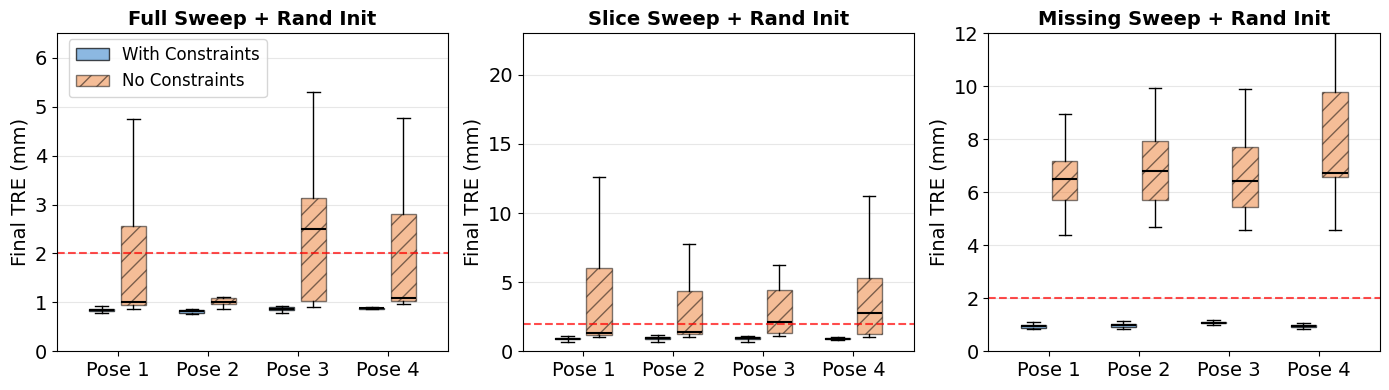

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from pathlib import Path

# Base path - UPDATE THIS to your actual path
BASE_PATH = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/experiments"

# Define the structure
poses = ['sofa1', 'sofa3', 'sofa6', 'sofa5']  # Corresponds to Pose 1, 2, 3
conditions = ['full', 'slice', 'missing']
vertebrae = ['L1', 'L2', 'L3', 'L4']

def load_tre_data(filepath):
    """
    Load TRE data from JSON file and return mean across vertebrae for each run.
    
    Expected return format:
    [list of mean TRE values across all vertebrae for each run]
    """
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
        
        mean_tre_list = []
        
        # Extract final_tre data from the first (and typically only) entry
        for key in data.keys():
            if key != '_summary' and 'final_tre' in data[key]:
                final_tre_list = data[key]['final_tre']
                
                # For each run, calculate mean TRE across all vertebrae
                for i, tre_dict in enumerate(final_tre_list):
                    vertebra_values = [tre_dict[vert] for vert in vertebrae]
                    mean_tre = np.mean(vertebra_values)
                    mean_tre_list.append(mean_tre)
                
                break  # Assuming one main entry per file
        
        return mean_tre_list
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def collect_data():
    """Collect all TRE data organized by condition and pose."""
    data = {
        'full_rand': {},             # Panel 1: full/robust_constraints.json
        'slice_rand': {},            # Panel 2: slice/robust_constraints.json
        'missing_rand': {},          # Panel 3: missing/robust_constraints.json
        'full_no_constraints': {},   # Panel 1: full/robust_no_constraints.json
        'slice_no_constraints': {},  # Panel 2: slice/robust_no_constraints.json
        'missing_no_constraints': {} # Panel 3: missing/robust_no_constraints.json
    }
    
    # Initialize data structure for each pose
    for panel in data.keys():
        for pose_idx in range(len(poses)):
            data[panel][f'Pose {pose_idx + 1}'] = []
    
    for pose_idx, pose in enumerate(poses):
        pose_name = f'Pose {pose_idx + 1}'
        
        # Full sweep - random init
        full_rand_path = os.path.join(BASE_PATH, pose, 'full', '30', 'robust_constraints.json')
        if os.path.exists(full_rand_path):
            full_rand_data = load_tre_data(full_rand_path)
            if full_rand_data:
                data['full_rand'][pose_name] = full_rand_data
        else:
            print(f"Warning: File not found: {full_rand_path}")
        
        # Full sweep - no constraints
        full_no_constraints_path = os.path.join(BASE_PATH, pose, 'full', '30', 'robust_no_constraints.json')
        if os.path.exists(full_no_constraints_path):
            full_no_constraints_data = load_tre_data(full_no_constraints_path)
            if full_no_constraints_data:
                data['full_no_constraints'][pose_name] = full_no_constraints_data
        else:
            print(f"Warning: File not found: {full_no_constraints_path}")
        
        # Slice sweep - random init
        slice_rand_path = os.path.join(BASE_PATH, pose, 'slice', '30', 'robust_constraints.json')
        if os.path.exists(slice_rand_path):
            slice_rand_data = load_tre_data(slice_rand_path)
            if slice_rand_data:
                data['slice_rand'][pose_name] = slice_rand_data
        else:
            print(f"Warning: File not found: {slice_rand_path}")
        
        # Slice sweep - no constraints
        slice_no_constraints_path = os.path.join(BASE_PATH, pose, 'slice', '30', 'robust_no_constraints.json')
        if os.path.exists(slice_no_constraints_path):
            slice_no_constraints_data = load_tre_data(slice_no_constraints_path)
            if slice_no_constraints_data:
                data['slice_no_constraints'][pose_name] = slice_no_constraints_data
        else:
            print(f"Warning: File not found: {slice_no_constraints_path}")
        
        # Missing sweep - random init
        missing_rand_path = os.path.join(BASE_PATH, pose, 'missing', '30', 'robust_constraints.json')
        if os.path.exists(missing_rand_path):
            missing_rand_data = load_tre_data(missing_rand_path)
            if missing_rand_data:
                data['missing_rand'][pose_name] = missing_rand_data
        else:
            print(f"Warning: File not found: {missing_rand_path}")
        
        # Missing sweep - no constraints
        missing_no_constraints_path = os.path.join(BASE_PATH, pose, 'missing', '30', 'robust_no_constraints.json')
        if os.path.exists(missing_no_constraints_path):
            missing_no_constraints_data = load_tre_data(missing_no_constraints_path)
            if missing_no_constraints_data:
                data['missing_no_constraints'][pose_name] = missing_no_constraints_data
        else:
            print(f"Warning: File not found: {missing_no_constraints_path}")
    
    return data

def print_statistics(data):
    """Print mean, median, and standard deviation for each condition and pose."""
    print("\n" + "="*80)
    print("TRE STATISTICS (Mean ± Std Dev / Median in mm)")
    print("="*80)
    
    conditions_pairs = [
        ('full_rand', 'full_no_constraints', 'Full Sweep + Rand Init'),
        ('slice_rand', 'slice_no_constraints', 'Slice Sweep + Rand Init'),
        ('missing_rand', 'missing_no_constraints', 'Missing Sweep + Rand Init')
    ]
    
    # Store overall values for summary
    overall_summary_with = {}
    overall_summary_without = {}
    
    for with_constraints_key, no_constraints_key, title in conditions_pairs:
        print(f"\n{title}")
        print("-" * 80)
        
        # Collect all values for overall statistics
        all_values_with = []
        all_values_without = []
        
        for pose_idx in range(len(poses)):
            pose_name = f'Pose {pose_idx + 1}'
            print(f"\n  {pose_name}:")
            
            # With constraints
            if pose_name in data[with_constraints_key] and len(data[with_constraints_key][pose_name]) > 0:
                values = data[with_constraints_key][pose_name]
                mean_val = np.mean(values)
                median_val = np.median(values)
                std_val = np.std(values)
                n = len(values)
                print(f"    With Constraints:    {mean_val:.3f} ± {std_val:.3f} mm  (median: {median_val:.3f})  (n={n})")
                all_values_with.extend(values)
            else:
                print(f"    With Constraints:    No data available")
            
            # No constraints
            if pose_name in data[no_constraints_key] and len(data[no_constraints_key][pose_name]) > 0:
                values = data[no_constraints_key][pose_name]
                mean_val = np.mean(values)
                median_val = np.median(values)
                std_val = np.std(values)
                n = len(values)
                print(f"    No Constraints:      {mean_val:.3f} ± {std_val:.3f} mm  (median: {median_val:.3f})  (n={n})")
                all_values_without.extend(values)
            else:
                print(f"    No Constraints:      No data available")
        
        # Print overall statistics for this condition
        print(f"\n  OVERALL (all poses):")
        if len(all_values_with) > 0:
            overall_mean_with = np.mean(all_values_with)
            overall_median_with = np.median(all_values_with)
            overall_std_with = np.std(all_values_with)
            overall_n_with = len(all_values_with)
            print(f"    With Constraints:    {overall_mean_with:.3f} ± {overall_std_with:.3f} mm  (median: {overall_median_with:.3f})  (n={overall_n_with})")
            overall_summary_with[title] = (overall_mean_with, overall_median_with, overall_std_with, overall_n_with)
        else:
            print(f"    With Constraints:    No data available")
            overall_summary_with[title] = None
        
        if len(all_values_without) > 0:
            overall_mean_without = np.mean(all_values_without)
            overall_median_without = np.median(all_values_without)
            overall_std_without = np.std(all_values_without)
            overall_n_without = len(all_values_without)
            print(f"    No Constraints:      {overall_mean_without:.3f} ± {overall_std_without:.3f} mm  (median: {overall_median_without:.3f})  (n={overall_n_without})")
            overall_summary_without[title] = (overall_mean_without, overall_median_without, overall_std_without, overall_n_without)
        else:
            print(f"    No Constraints:      No data available")
            overall_summary_without[title] = None
    
    # Print summary comparison
    print("\n" + "="*80)
    print("SUMMARY: Overall Mean TRE Across All Poses")
    print("="*80)
    print("\nWith Constraints:")
    print("-" * 80)
    for title in ['Full Sweep + Rand Init', 'Slice Sweep + Rand Init', 'Missing Sweep + Rand Init']:
        if overall_summary_with.get(title):
            mean, median, std, n = overall_summary_with[title]
            print(f"  {title:30s}:  {mean:.3f} ± {std:.3f} mm  (median: {median:.3f})  (n={n})")
        else:
            print(f"  {title:30s}:  No data available")
    
    print("\nNo Constraints:")
    print("-" * 80)
    for title in ['Full Sweep + Rand Init', 'Slice Sweep + Rand Init', 'Missing Sweep + Rand Init']:
        if overall_summary_without.get(title):
            mean, median, std, n = overall_summary_without[title]
            print(f"  {title:30s}:  {mean:.3f} ± {std:.3f} mm  (median: {median:.3f})  (n={n})")
        else:
            print(f"  {title:30s}:  No data available")
    
    print("="*80 + "\n")

def create_boxplot(ax, data_dict_with_constraints, data_dict_no_constraints, title, ylim=20):
    """Create a single subplot with box plots for both with and without constraints."""
    
    pose_labels = ['Pose 1', 'Pose 2', 'Pose 3', 'Pose 4']
    positions_base = np.arange(len(pose_labels))
    width = 0.35
    
    # Collect data for each pose
    plot_data_constraints = []
    plot_data_no_constraints = []
    
    for pose_idx in range(len(poses)):
        pose_name = f'Pose {pose_idx + 1}'
        
        # With constraints
        if pose_name in data_dict_with_constraints:
            plot_data_constraints.append(data_dict_with_constraints[pose_name])
        else:
            plot_data_constraints.append([])
        
        # No constraints
        if pose_name in data_dict_no_constraints:
            plot_data_no_constraints.append(data_dict_no_constraints[pose_name])
        else:
            plot_data_no_constraints.append([])
    
    # Plot with constraints (solid, left position)
    positions_constraints = positions_base - width/2
    bp1 = ax.boxplot(plot_data_constraints, positions=positions_constraints, widths=width*0.8,
                   patch_artist=True, showfliers=False,
                   boxprops=dict(facecolor='#5B9BD5', alpha=0.7),
                   medianprops=dict(color='black', linewidth=1.5),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'))
    
    # Plot without constraints (hatched, right position)
    positions_no_constraints = positions_base + width/2
    bp2 = ax.boxplot(plot_data_no_constraints, positions=positions_no_constraints, widths=width*0.8,
                   patch_artist=True, showfliers=False,
                   boxprops=dict(facecolor='#ED7D31', alpha=0.5, hatch='//'),
                   medianprops=dict(color='black', linewidth=1.5),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'))
    
    # Add reference line at 2.0 mm
    ax.axhline(y=2.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Formatting
    ax.set_xticks(positions_base)
    ax.set_xticklabels(pose_labels)
    ax.set_ylabel('Final TRE (mm)', fontsize=14)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylim(0, ylim) 
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set tick label font size - ADD THIS LINE
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    return bp1, bp2

def main():
    # Collect all data
    print("Collecting data...")
    data = collect_data()
    
    # Print statistics
    print_statistics(data)
    
    # Create figure with 1x3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    
    # Plot each condition with random initialization (both with and without constraints)
    # You can adjust the ylim parameter for each subplot as needed
    boxes1 = create_boxplot(axes[0], data['full_rand'], data['full_no_constraints'],
                           'Full Sweep + Rand Init', ylim=6.5)
    boxes2 = create_boxplot(axes[1], data['slice_rand'], data['slice_no_constraints'],
                           'Slice Sweep + Rand Init', ylim=23)
    boxes3 = create_boxplot(axes[2], data['missing_rand'], data['missing_no_constraints'],
                           'Missing Sweep + Rand Init', ylim=12)
    
    # Add legend
    legend_elements = [
        plt.Rectangle((0,0),1,1, facecolor='#5B9BD5', alpha=0.7, 
                     edgecolor='black', label='With Constraints'),
        plt.Rectangle((0,0),1,1, facecolor='#ED7D31', alpha=0.5, 
                     edgecolor='black', hatch='//', label='No Constraints')
    ]
    
    fig.legend(handles=legend_elements, loc='upper right', 
              bbox_to_anchor=(0.20, 0.91), frameon=True, fontsize=12)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()
    # Title = 'Figure 2: Final TRE Distribution by Pose (Mean across vertebrae, Random Initialization)'


full_constraints: Collected 120 runs (mean across vertebrae)
  Final TRE range: 0.75 - 15.85 mm
  Success rate (mean TRE < 2.0mm): 99.2% (119/120)
full_no_constraints: Collected 120 runs (mean across vertebrae)
  Final TRE range: 0.86 - 16.56 mm
  Success rate (mean TRE < 2.0mm): 59.2% (71/120)
slice_constraints: Collected 120 runs (mean across vertebrae)
  Final TRE range: 0.68 - 15.84 mm
  Success rate (mean TRE < 2.0mm): 98.3% (118/120)
slice_no_constraints: Collected 120 runs (mean across vertebrae)
  Final TRE range: 1.02 - 18.52 mm
  Success rate (mean TRE < 2.0mm): 53.3% (64/120)
missing_constraints: Collected 120 runs (mean across vertebrae)
  Final TRE range: 0.84 - 16.53 mm
  Success rate (mean TRE < 2.0mm): 98.3% (118/120)
missing_no_constraints: Collected 120 runs (mean across vertebrae)
  Final TRE range: 4.39 - 18.36 mm
  Success rate (mean TRE < 2.0mm): 0.0% (0/120)

SUMMARY STATISTICS (Success = Mean TRE < 2.0 mm)

Full Sweep + Random Init:
  With Constraints:
    Succe

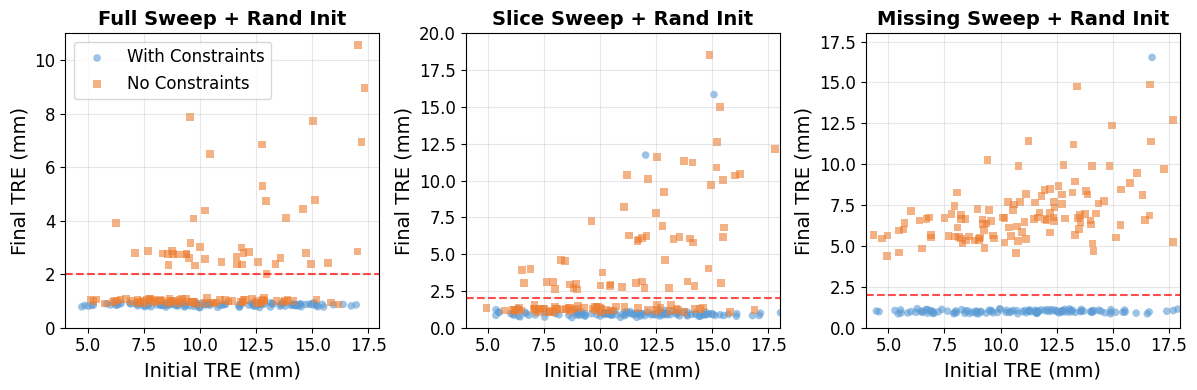

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from pathlib import Path

# Base path - UPDATE THIS to your actual path
BASE_PATH = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/experiments"

# Define the structure
poses = ['sofa1', 'sofa3', 'sofa6', 'sofa5']  # Corresponds to Pose 1, 2, 3
vertebrae = ['L1', 'L2', 'L3', 'L4']

def load_tre_data(filepath):
    """
    Load TRE data from JSON file.
    
    Returns:
    {
        'final_tre': {'L1': [...], 'L2': [...], 'L3': [...], 'L4': [...]},
        'initial_tre': {'L1': [...], 'L2': [...], 'L3': [...], 'L4': [...]},
        'success': {'L1': [...], 'L2': [...], 'L3': [...], 'L4': [...]}
    }
    """
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
        
        result = {
            'final_tre': {'L1': [], 'L2': [], 'L3': [], 'L4': []},
            'initial_tre': {'L1': [], 'L2': [], 'L3': [], 'L4': []},
            'success': {'L1': [], 'L2': [], 'L3': [], 'L4': []}
        }
        
        # Extract data from the first (and typically only) entry
        for key in data.keys():
            if key != '_summary' and 'final_tre' in data[key]:
                final_tre_list = data[key]['final_tre']
                initial_tre_list = data[key]['initial_tre']
                success_list = data[key]['per_vertebra_success']
                
                # Collect values for each vertebra across all runs
                for i, (final_dict, initial_dict, success_dict) in enumerate(zip(final_tre_list, initial_tre_list, success_list)):
                    for vert in vertebrae:
                        result['final_tre'][vert].append(final_dict[vert])
                        result['initial_tre'][vert].append(initial_dict[vert])
                        result['success'][vert].append(success_dict.get(vert, False))
                
                break  # Assuming one main entry per file
        
        return result
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def collect_pooled_data():
    """Collect data pooled across all 3 poses, with mean TRE across vertebrae for each run."""
    pooled_data = {
        'full_constraints': {'initial': [], 'final': [], 'success': []},
        'full_no_constraints': {'initial': [], 'final': [], 'success': []},
        'slice_constraints': {'initial': [], 'final': [], 'success': []},
        'slice_no_constraints': {'initial': [], 'final': [], 'success': []},
        'missing_constraints': {'initial': [], 'final': [], 'success': []},
        'missing_no_constraints': {'initial': [], 'final': [], 'success': []}
    }
    
    conditions_map = {
        'full_constraints': ('full', 'robust_constraints.json'),
        'full_no_constraints': ('full', 'robust_no_constraints.json'),
        'slice_constraints': ('slice', 'robust_constraints.json'),
        'slice_no_constraints': ('slice', 'robust_no_constraints.json'),
        'missing_constraints': ('missing', 'robust_constraints.json'),
        'missing_no_constraints': ('missing', 'robust_no_constraints.json')
    }
    
    # Pool data across all 3 poses with mean across vertebrae
    for cond_key, (folder, filename) in conditions_map.items():
        total_collected = 0
        all_final_tres = []
        for pose in poses:
            filepath = os.path.join(BASE_PATH, pose, folder, '30', filename)
            
            if os.path.exists(filepath):
                data = load_tre_data(filepath)
                if data:
                    # Determine number of runs (assume all vertebrae have same number of runs)
                    num_runs = len(data['initial_tre']['L1'])
                    
                    # For each run, calculate mean across all vertebrae
                    for i in range(num_runs):
                        initial_values = [data['initial_tre'][vert][i] for vert in vertebrae]
                        final_values = [data['final_tre'][vert][i] for vert in vertebrae]
                        
                        mean_initial = np.mean(initial_values)
                        mean_final = np.mean(final_values)
                        
                        # Consider run successful if mean TRE < 2.0 mm
                        run_success = mean_final < 2.0
                        
                        pooled_data[cond_key]['initial'].append(mean_initial)
                        pooled_data[cond_key]['final'].append(mean_final)
                        pooled_data[cond_key]['success'].append(run_success)
                        all_final_tres.append(mean_final)
                        total_collected += 1
            else:
                print(f"Warning: File not found: {filepath}")
        
        if all_final_tres:
            success_rate = 100 * np.mean(pooled_data[cond_key]['success'])
            print(f"{cond_key}: Collected {total_collected} runs (mean across vertebrae)")
            print(f"  Final TRE range: {min(all_final_tres):.2f} - {max(all_final_tres):.2f} mm")
            print(f"  Success rate (mean TRE < 2.0mm): {success_rate:.1f}% ({sum(pooled_data[cond_key]['success'])}/{len(pooled_data[cond_key]['success'])})")
        else:
            print(f"{cond_key}: No data collected!")
    
    return pooled_data

def create_scatter_plot(ax, data_with_constraints, data_no_constraints, title, xlim=(4, 20), ylim=(0, 20), show_legend=True):
    """Create a single scatter plot comparing constraints vs no constraints."""
    
    # Plot with constraints (blue, solid)
    ax.scatter(data_with_constraints['initial'], data_with_constraints['final'], 
              c='#5B9BD5', label='With Constraints', alpha=0.6, s=30, edgecolors='none')
    
    # Plot without constraints (orange, hatched appearance via marker)
    ax.scatter(data_no_constraints['initial'], data_no_constraints['final'], 
              c='#ED7D31', label='No Constraints', alpha=0.6, s=30, 
              edgecolors='none', marker='s')
    
    # Add horizontal reference line at 2.0 mm
    ax.axhline(y=2.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)
    
    # Formatting
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('Initial TRE (mm)', fontsize=14)
    ax.set_ylabel('Final TRE (mm)', fontsize=14)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Set tick label font size - ADD THIS LINE
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Only show legend if requested
    if show_legend:
        ax.legend(loc='upper left', frameon=True, fontsize = 12)

def main():
    print("Collecting pooled data across all poses (mean across vertebrae per run)...")
    print("="*80)
    data = collect_pooled_data()
    print("="*80)
    
    # Print summary statistics
    print("\n" + "="*80)
    print("SUMMARY STATISTICS (Success = Mean TRE < 2.0 mm)")
    print("="*80)
    
    conditions = [
        ('Full Sweep + Random Init', 'full_constraints', 'full_no_constraints'),
        ('Slice Sweep + Random Init', 'slice_constraints', 'slice_no_constraints'),
        ('Missing Sweep + Random Init', 'missing_constraints', 'missing_no_constraints')
    ]
    
    for name, with_const, no_const in conditions:
        print(f"\n{name}:")
        print(f"  With Constraints:")
        print(f"    Success Rate: {100*np.mean(data[with_const]['success']):.1f}% "
              f"({sum(data[with_const]['success'])}/{len(data[with_const]['success'])})")
        print(f"    Mean Final TRE: {np.mean(data[with_const]['final']):.2f} ± {np.std(data[with_const]['final']):.2f} mm")
        
        print(f"  No Constraints:")
        print(f"    Success Rate: {100*np.mean(data[no_const]['success']):.1f}% "
              f"({sum(data[no_const]['success'])}/{len(data[no_const]['success'])})")
        print(f"    Mean Final TRE: {np.mean(data[no_const]['final']):.2f} ± {np.std(data[no_const]['final']):.2f} mm")
    
    print("="*80 + "\n")
    
    # Create figure with 1x3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # Plot each condition
    create_scatter_plot(axes[0], data['full_constraints'], data['full_no_constraints'],
                       'Full Sweep + Rand Init', xlim=(4, 18), ylim=(0, 11), show_legend=True)
    
    create_scatter_plot(axes[1], data['slice_constraints'], data['slice_no_constraints'],
                       'Slice Sweep + Rand Init', xlim=(4, 18), ylim=(0, 20), show_legend=False)
    
    create_scatter_plot(axes[2], data['missing_constraints'], data['missing_no_constraints'],
                       'Missing Sweep + Rand Init', xlim=(4, 18), ylim=(0, 18), show_legend=False)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [20]:
import json
import numpy as np

BASE_PATH = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/experiments"
poses = ['sofa1', 'sofa3', 'sofa6', 'sofa5']
vertebrae = ['L1', 'L2', 'L3', 'L4']

# Collect all values per vertebra across all poses
all_final = {v: [] for v in vertebrae}
all_angles = {v: [] for v in vertebrae}

for pose in poses:
    filepath = f"{BASE_PATH}/{pose}/full/30/robust_constraints.json"
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    key = [k for k in data.keys() if k != '_summary'][0]
    entry = data[key]
    
    for vert in vertebrae:
        all_final[vert].extend([d[vert] for d in entry['final_tre']])
        all_angles[vert].extend([d[vert] for d in entry['angular_errors']])

# Compute stats
rows = {'Median TRE': [], 'Mean TRE': [], 'Mean Angle Error (°)': []}

for vert in vertebrae:
    rows['Median TRE'].append(np.median(all_final[vert]))
    rows['Mean TRE'].append(np.mean(all_final[vert]))
    rows['Mean Angle Error (°)'].append(np.mean(all_angles[vert]))

# All column: pool everything
pooled_final = [v for vals in all_final.values() for v in vals]
pooled_angles = [v for vals in all_angles.values() for v in vals]
rows['Median TRE'].append(np.median(pooled_final))
rows['Mean TRE'].append(np.mean(pooled_final))
rows['Mean Angle Error (°)'].append(np.mean(pooled_angles))

# Print table
cols = vertebrae + ['All']
header = f"{'':25s}" + "".join(f"{c:>8s}" for c in cols)
print("Table 4")
print("TRE and angle error per vertebra (robust full sweep all poses)\n")
print(header)
print("-" * len(header))
for row_name, values in rows.items():
    print(f"{row_name:25s}" + "".join(f"{v:8.3f}" for v in values))

Table 4
TRE and angle error per vertebra (robust full sweep all poses)

                               L1      L2      L3      L4     All
-----------------------------------------------------------------
Median TRE                  0.825   0.836   0.831   0.902   0.868
Mean TRE                    0.908   0.968   1.001   1.029   0.976
Mean Angle Error (°)        1.117   1.223   0.756   2.089   1.296


In [21]:
import json
import numpy as np

BASE_PATH = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/experiments"
poses = ['sofa1', 'sofa3', 'sofa6', 'sofa5']
curvatures = ['Anterior1', 'Anterior2', 'Left', 'Posterior']
vertebrae = ['L1', 'L2', 'L3', 'L4']

rows = []

for pose, curvature in zip(poses, curvatures):
    filepath = f"{BASE_PATH}/{pose}/full/30/robust_constraints.json"
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    key = [k for k in data.keys() if k != '_summary'][0]
    entry = data[key]

    # Pool across all vertebrae for each run, then compute mean TRE per run
    final_tres = []
    for run in entry['final_tre']:
        final_tres.append(np.mean([run[v] for v in vertebrae]))
    
    angles = []
    for run in entry['angular_errors']:
        angles.append(np.mean([run[v] for v in vertebrae]))
    
    success = entry['success']
    success_rate = 100 * np.mean(success)

    rows.append({
        'curvature': curvature,
        'tre_mean': np.mean(final_tres),
        'tre_std': np.std(final_tres),
        'ang_mean': np.mean(angles),
        'ang_std': np.std(angles),
        'success_rate': success_rate
    })

# Print table
print("Table 5")
print("Mean TRE (mm), angular error (°) and total success rate (robust full sweep all poses)\n")
print(f"{'Curvature':<14} {'Mean TRE ± std (mm)':<24} {'Angular Error ± std (°)':<26} {'Success Rate'}")
print("-" * 80)
for r in rows:
    tre_str = f"{r['tre_mean']:.3f} ± {r['tre_std']:.3f}"
    ang_str = f"{r['ang_mean']:.3f} ± {r['ang_std']:.3f}"
    print(f"{r['curvature']:<14} {tre_str:<24} {ang_str:<26} {r['success_rate']:.1f}%")

Table 5
Mean TRE (mm), angular error (°) and total success rate (robust full sweep all poses)

Curvature      Mean TRE ± std (mm)      Angular Error ± std (°)    Success Rate
--------------------------------------------------------------------------------
Anterior1      0.848 ± 0.042            0.973 ± 0.051              100.0%
Anterior2      0.810 ± 0.031            1.148 ± 0.067              100.0%
Left           0.870 ± 0.038            1.393 ± 0.064              100.0%
Posterior      1.379 ± 2.688            1.672 ± 1.361              96.7%


STATISTICAL ANALYSIS: T-TESTS AND THRESHOLD ANALYSIS

1. PAIRED T-TESTS: Final TRE (With Constraints vs No Constraints)

Full Sweep + Rand Init:
  With Constraints:    0.842 ± 0.045 mm (n=90)
  No Constraints:      2.200 ± 2.276 mm (n=90)
  Mean Difference:     -1.358 mm
  Paired t-test:       t = -5.680, p = 0.000000
  Cohen's d:           -0.599
  Significance:        *** (p < 0.001)

Slice Sweep + Rand Init:
  With Constraints:    1.223 ± 1.933 mm (n=90)
  No Constraints:      3.473 ± 3.448 mm (n=90)
  Mean Difference:     -2.250 mm
  Paired t-test:       t = -5.791, p = 0.000000
  Cohen's d:           -0.610
  Significance:        *** (p < 0.001)

Missing Sweep + Rand Init:
  With Constraints:    1.181 ± 1.638 mm (n=90)
  No Constraints:      6.875 ± 1.630 mm (n=90)
  Mean Difference:     -5.694 mm
  Paired t-test:       t = -23.312, p = 0.000000
  Cohen's d:           -2.457
  Significance:        *** (p < 0.001)

2. SUCCESS RATE ANALYSIS (Final TRE < 2mm)

Full Sweep + Rand Init:

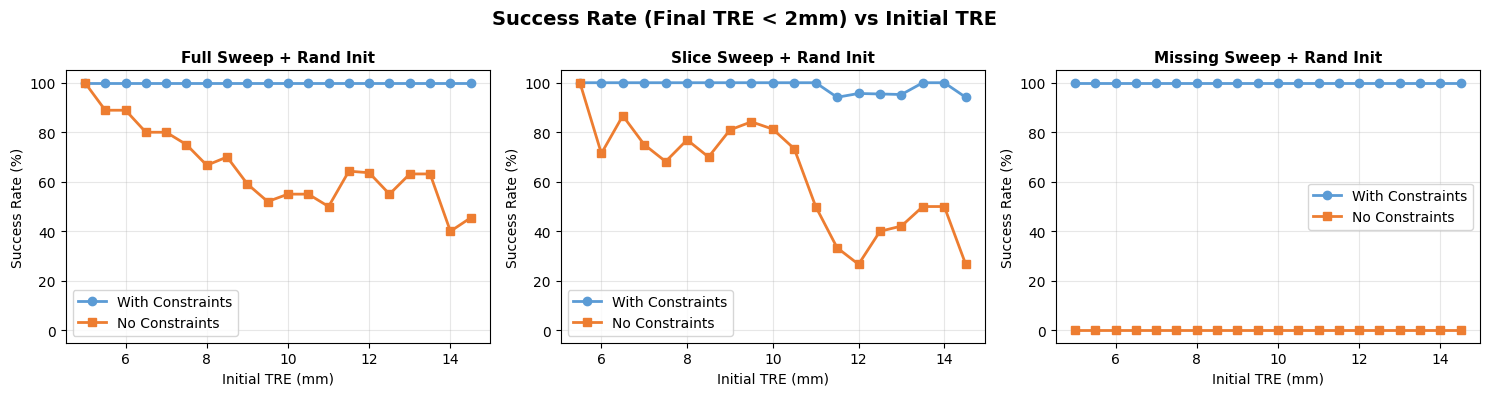


ANALYSIS COMPLETE


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from scipy import stats
from pathlib import Path

# Base path - UPDATE THIS to your actual path
BASE_PATH = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/experiments"

# Define the structure
poses = ['sofa1', 'sofa3', 'sofa6']
vertebrae = ['L1', 'L2', 'L3', 'L4']

def load_tre_data_with_initial(filepath):
    """
    Load TRE data from JSON file including both initial and final TRE.
    
    Returns:
    {
        'final_tre': [list of mean final TRE across vertebrae for each run],
        'initial_tre': [list of mean initial TRE across vertebrae for each run]
    }
    """
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
        
        final_tre_list = []
        initial_tre_list = []
        
        # Extract data from the first (and typically only) entry
        for key in data.keys():
            if key != '_summary' and 'final_tre' in data[key]:
                final_tre_data = data[key]['final_tre']
                initial_tre_data = data[key]['initial_tre']
                
                # For each run, calculate mean TRE across all vertebrae
                for final_dict, initial_dict in zip(final_tre_data, initial_tre_data):
                    final_values = [final_dict[vert] for vert in vertebrae]
                    initial_values = [initial_dict[vert] for vert in vertebrae]
                    
                    final_tre_list.append(np.mean(final_values))
                    initial_tre_list.append(np.mean(initial_values))
                
                break
        
        return {'final_tre': final_tre_list, 'initial_tre': initial_tre_list}
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def collect_all_data():
    """Collect all data with both initial and final TRE values."""
    data = {
        'full_constraints': {'initial': [], 'final': []},
        'full_no_constraints': {'initial': [], 'final': []},
        'slice_constraints': {'initial': [], 'final': []},
        'slice_no_constraints': {'initial': [], 'final': []},
        'missing_constraints': {'initial': [], 'final': []},
        'missing_no_constraints': {'initial': [], 'final': []}
    }
    
    conditions_map = {
        'full_constraints': ('full', 'robust_constraints.json'),
        'full_no_constraints': ('full', 'robust_no_constraints.json'),
        'slice_constraints': ('slice', 'robust_constraints.json'),
        'slice_no_constraints': ('slice', 'robust_no_constraints.json'),
        'missing_constraints': ('missing', 'robust_constraints.json'),
        'missing_no_constraints': ('missing', 'robust_no_constraints.json')
    }
    
    for cond_key, (folder, filename) in conditions_map.items():
        for pose in poses:
            filepath = os.path.join(BASE_PATH, pose, folder, '30', filename)
            
            if os.path.exists(filepath):
                tre_data = load_tre_data_with_initial(filepath)
                if tre_data:
                    data[cond_key]['initial'].extend(tre_data['initial_tre'])
                    data[cond_key]['final'].extend(tre_data['final_tre'])
    
    return data

# ============================================================================
# STATISTICAL TESTS
# ============================================================================

print("="*80)
print("STATISTICAL ANALYSIS: T-TESTS AND THRESHOLD ANALYSIS")
print("="*80)

# Collect data
data = collect_all_data()

# ============================================================================
# 1. PAIRED T-TESTS: With Constraints vs No Constraints
# ============================================================================

print("\n" + "="*80)
print("1. PAIRED T-TESTS: Final TRE (With Constraints vs No Constraints)")
print("="*80)

conditions = [
    ('full_constraints', 'full_no_constraints', 'Full Sweep + Rand Init'),
    ('slice_constraints', 'slice_no_constraints', 'Slice Sweep + Rand Init'),
    ('missing_constraints', 'missing_no_constraints', 'Missing Sweep + Rand Init')
]

for with_key, without_key, label in conditions:
    final_with = np.array(data[with_key]['final'])
    final_without = np.array(data[without_key]['final'])
    
    # Ensure same length for paired test
    min_len = min(len(final_with), len(final_without))
    final_with = final_with[:min_len]
    final_without = final_without[:min_len]
    
    # Paired t-test
    t_stat, p_value = stats.ttest_rel(final_with, final_without)
    
    # Calculate effect size (Cohen's d for paired samples)
    diff = final_with - final_without
    cohens_d = np.mean(diff) / np.std(diff, ddof=1)
    
    # Summary statistics
    mean_with = np.mean(final_with)
    mean_without = np.mean(final_without)
    std_with = np.std(final_with, ddof=1)
    std_without = np.std(final_without, ddof=1)
    
    print(f"\n{label}:")
    print(f"  With Constraints:    {mean_with:.3f} ± {std_with:.3f} mm (n={len(final_with)})")
    print(f"  No Constraints:      {mean_without:.3f} ± {std_without:.3f} mm (n={len(final_without)})")
    print(f"  Mean Difference:     {mean_with - mean_without:.3f} mm")
    print(f"  Paired t-test:       t = {t_stat:.3f}, p = {p_value:.6f}")
    print(f"  Cohen's d:           {cohens_d:.3f}")
    
    if p_value < 0.001:
        print(f"  Significance:        *** (p < 0.001)")
    elif p_value < 0.01:
        print(f"  Significance:        ** (p < 0.01)")
    elif p_value < 0.05:
        print(f"  Significance:        * (p < 0.05)")
    else:
        print(f"  Significance:        ns (not significant)")

# ============================================================================
# 2. SUCCESS RATE ANALYSIS (TRE < 2mm)
# ============================================================================

print("\n" + "="*80)
print("2. SUCCESS RATE ANALYSIS (Final TRE < 2mm)")
print("="*80)

for with_key, without_key, label in conditions:
    final_with = np.array(data[with_key]['final'])
    final_without = np.array(data[without_key]['final'])
    
    success_with = np.sum(final_with < 2.0)
    success_without = np.sum(final_without < 2.0)
    total_with = len(final_with)
    total_without = len(final_without)
    
    success_rate_with = 100 * success_with / total_with if total_with > 0 else 0
    success_rate_without = 100 * success_without / total_without if total_without > 0 else 0
    
    # Fisher's exact test
    contingency_table = [[success_with, total_with - success_with],
                        [success_without, total_without - success_without]]
    odds_ratio, p_value_fisher = stats.fisher_exact(contingency_table)
    
    print(f"\n{label}:")
    print(f"  With Constraints:    {success_with}/{total_with} ({success_rate_with:.1f}%)")
    print(f"  No Constraints:      {success_without}/{total_without} ({success_rate_without:.1f}%)")
    print(f"  Fisher's exact test: p = {p_value_fisher:.6f}")
    print(f"  Odds ratio:          {odds_ratio:.3f}")

# ============================================================================
# 3. INITIAL TRE THRESHOLD ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("3. INITIAL TRE THRESHOLD ANALYSIS")
print("="*80)
print("At what initial TRE do constraints become critical?")
print("="*80)

# Define threshold bins
thresholds = np.arange(4, 16, 1)

for with_key, without_key, label in conditions:
    initial_with = np.array(data[with_key]['initial'])
    final_with = np.array(data[with_key]['final'])
    initial_without = np.array(data[without_key]['initial'])
    final_without = np.array(data[without_key]['final'])
    
    print(f"\n{label}:")
    print(f"  Initial TRE Range | Success Rate (With) | Success Rate (No) | Difference")
    print(f"  " + "-"*70)
    
    for i in range(len(thresholds) - 1):
        low = thresholds[i]
        high = thresholds[i + 1]
        
        # Filter data in this range
        mask_with = (initial_with >= low) & (initial_with < high)
        mask_without = (initial_without >= low) & (initial_without < high)
        
        if np.sum(mask_with) > 0 and np.sum(mask_without) > 0:
            success_with = np.sum((final_with[mask_with] < 2.0)) / np.sum(mask_with) * 100
            success_without = np.sum((final_without[mask_without] < 2.0)) / np.sum(mask_without) * 100
            diff = success_with - success_without
            
            n_with = np.sum(mask_with)
            n_without = np.sum(mask_without)
            
            print(f"  [{low:4.1f}, {high:4.1f}) mm  | {success_with:6.1f}% (n={n_with:2d})   | "
                  f"{success_without:6.1f}% (n={n_without:2d}) | {diff:+6.1f}%")

# ============================================================================
# 4. VISUALIZATION: Success Rate vs Initial TRE
# ============================================================================

print("\n" + "="*80)
print("4. CREATING VISUALIZATION: Success Rate vs Initial TRE Threshold")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Success Rate (Final TRE < 2mm) vs Initial TRE', 
             fontsize=14, fontweight='bold')

for idx, (with_key, without_key, label) in enumerate(conditions):
    ax = axes[idx]
    
    initial_with = np.array(data[with_key]['initial'])
    final_with = np.array(data[with_key]['final'])
    initial_without = np.array(data[without_key]['initial'])
    final_without = np.array(data[without_key]['final'])
    
    # Calculate success rates for sliding windows
    window_centers = []
    success_rates_with = []
    success_rates_without = []
    
    for center in np.arange(5, 15, 0.5):
        window_size = 2.0
        low = center - window_size / 2
        high = center + window_size / 2
        
        mask_with = (initial_with >= low) & (initial_with < high)
        mask_without = (initial_without >= low) & (initial_without < high)
        
        if np.sum(mask_with) >= 3 and np.sum(mask_without) >= 3:  # At least 3 samples
            success_with = np.sum((final_with[mask_with] < 2.0)) / np.sum(mask_with) * 100
            success_without = np.sum((final_without[mask_without] < 2.0)) / np.sum(mask_without) * 100
            
            window_centers.append(center)
            success_rates_with.append(success_with)
            success_rates_without.append(success_without)
    
    # Plot
    ax.plot(window_centers, success_rates_with, 'o-', color='#5B9BD5', 
            label='With Constraints', linewidth=2, markersize=6)
    ax.plot(window_centers, success_rates_without, 's-', color='#ED7D31', 
            label='No Constraints', linewidth=2, markersize=6)
    
    ax.set_xlabel('Initial TRE (mm)', fontsize=10)
    ax.set_ylabel('Success Rate (%)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-5, 105)
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

In [14]:
# import matplotlib.pyplot as plt
# import numpy as np
# import json
# import os
# from pathlib import Path

# # Base path - UPDATE THIS to your actual path
# BASE_PATH = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/experiments"

# # Define the structure
# poses = ['sofa1', 'sofa3', 'sofa6', 'sofa5']  # Corresponds to Pose 1, 2, 3
# conditions = ['full', 'slice', 'missing']
# vertebrae = ['L1', 'L2', 'L3', 'L4']

# def load_tre_data(filepath):
#     """
#     Load TRE data from JSON file.
    
#     Returns:
#     {
#         'final_tre': {'L1': [...], 'L2': [...], 'L3': [...], 'L4': [...]},
#         'initial_tre': {'L1': [...], 'L2': [...], 'L3': [...], 'L4': [...]},
#         'success': {'L1': [...], 'L2': [...], 'L3': [...], 'L4': [...]}
#     }
#     """
#     try:
#         with open(filepath, 'r') as f:
#             data = json.load(f)
        
#         result = {
#             'final_tre': {'L1': [], 'L2': [], 'L3': [], 'L4': []},
#             'initial_tre': {'L1': [], 'L2': [], 'L3': [], 'L4': []},
#             'success': {'L1': [], 'L2': [], 'L3': [], 'L4': []}
#         }
        
#         # Extract data from the first (and typically only) entry
#         for key in data.keys():
#             if key != '_summary' and 'final_tre' in data[key]:
#                 final_tre_list = data[key]['final_tre']
#                 initial_tre_list = data[key]['initial_tre']
#                 success_list = data[key]['per_vertebra_success']
                
#                 # Collect values for each vertebra across all runs
#                 for i, (final_dict, initial_dict, success_dict) in enumerate(zip(final_tre_list, initial_tre_list, success_list)):
#                     for vert in vertebrae:
#                         result['final_tre'][vert].append(final_dict[vert])
#                         result['initial_tre'][vert].append(initial_dict[vert])
#                         result['success'][vert].append(success_dict.get(vert, False))
                
#                 break  # Assuming one main entry per file
        
#         return result
#     except Exception as e:
#         print(f"Error loading {filepath}: {e}")
#         return None

# def calculate_statistics(data_dict):
#     """Calculate success rate and mean TRE for each vertebra."""
#     stats = {}
    
#     for vert in vertebrae:
#         if vert in data_dict['success'] and data_dict['success'][vert]:
#             success_list = data_dict['success'][vert]
#             final_tre_list = data_dict['final_tre'][vert]
            
#             # Calculate success rate
#             success_count = sum(success_list)
#             total_count = len(success_list)
#             success_rate = (success_count / total_count * 100) if total_count > 0 else 0
            
#             # Calculate mean TRE (for ALL runs, not just successful ones)
#             mean_tre = np.mean(final_tre_list) if final_tre_list else 0
            
#             stats[vert] = {
#                 'success_rate': success_rate,
#                 'mean_tre': mean_tre,
#                 'success_count': success_count,
#                 'total_count': total_count
#             }
#         else:
#             stats[vert] = {
#                 'success_rate': 0,
#                 'mean_tre': 0,
#                 'success_count': 0,
#                 'total_count': 0
#             }
    
#     return stats

# def collect_all_statistics():
#     """Collect statistics for all conditions and poses."""
#     all_stats = {}
    
#     conditions_map = {
#         'full_normal': ('full', '30/constraints.json', 'Full Sweep'),
#         'full_rand': ('full', 'robust_constraints.json', 'Full + Rand Init'),
#         'slice_normal': ('slice', '30/constraints.json', 'Slice Sweep'),
#         'slice_rand': ('slice', 'robust_constraints.json', 'Slice + Rand Init'),
#         'missing_normal': ('missing', '30/constraints.json', 'Missing Sweep'),
#         'missing_rand': ('missing', 'robust_constraints.json', 'Missing + Rand Init')
#     }
    
#     for cond_key, (folder, filename, display_name) in conditions_map.items():
#         all_stats[cond_key] = {
#             'display_name': display_name,
#             'poses': {}
#         }
        
#         for pose_idx, pose in enumerate(poses):
#             pose_name = f'Pose {pose_idx + 1}'
#             filepath = os.path.join(BASE_PATH, pose, folder, filename)
            
#             if os.path.exists(filepath):
#                 data = load_tre_data(filepath)
#                 if data:
#                     stats = calculate_statistics(data)
#                     all_stats[cond_key]['poses'][pose_name] = stats
#             else:
#                 print(f"Warning: File not found: {filepath}")
#                 all_stats[cond_key]['poses'][pose_name] = {
#                     vert: {'success_rate': 0, 'mean_tre': 0, 'success_count': 0, 'total_count': 0}
#                     for vert in vertebrae
#                 }
    
#     return all_stats

# def create_summary_table():
#     """Create a summary table similar to the reference image."""
#     stats = collect_all_statistics()
    
#     # Create figure
#     fig, ax = plt.subplots(figsize=(14, 10))
#     ax.axis('tight')
#     ax.axis('off')
    
#     # Prepare data for the table
#     # Header row
#     header = ['Experiment', 'Pose', 'Success', 'L1 (mm / %)', 'L2 (mm / %)', 'L3 (mm / %)', 'L4 (mm / %)']
    
#     table_data = [header]
    
#     # Add data rows
#     condition_order = ['full_normal', 'full_rand', 'slice_normal', 'slice_rand', 'missing_normal', 'missing_rand']
    
#     for cond_key in condition_order:
#         if cond_key in stats:
#             display_name = stats[cond_key]['display_name']
            
#             for pose_idx, pose in enumerate(poses):
#                 pose_name = f'Pose {pose_idx + 1}'
                
#                 if pose_name in stats[cond_key]['poses']:
#                     pose_stats = stats[cond_key]['poses'][pose_name]
                    
#                     # Calculate overall success rate
#                     total_success = sum(pose_stats[vert]['success_count'] for vert in vertebrae)
#                     total_runs = sum(pose_stats[vert]['total_count'] for vert in vertebrae)
#                     overall_success = (total_success / total_runs * 100) if total_runs > 0 else 0
                    
#                     row = [
#                         display_name if pose_idx == 0 else '',
#                         pose_name,
#                         f"{overall_success:.1f}%"
#                     ]
                    
#                     # Add per-vertebra stats
#                     for vert in vertebrae:
#                         success_rate = pose_stats[vert]['success_rate']
#                         mean_tre = pose_stats[vert]['mean_tre']
#                         row.append(f"{mean_tre:.1f} / {success_rate:.0f}%")
                    
#                     table_data.append(row)
    
#     # Create table
#     table = ax.table(cellText=table_data, cellLoc='center', loc='center',
#                      colWidths=[0.15, 0.1, 0.1, 0.15, 0.15, 0.15, 0.15])
    
#     table.auto_set_font_size(False)
#     table.set_fontsize(10)
#     table.scale(1, 2.5)
    
#     # Style header row
#     for j in range(len(header)):
#         cell = table[(0, j)]
#         cell.set_facecolor('#4472C4')
#         cell.set_text_props(weight='bold', color='white')
    
#     # Style experiment name cells
#     for i in range(1, len(table_data)):
#         if table_data[i][0]:  # If experiment name is not empty
#             cell = table[(i, 0)]
#             cell.set_text_props(weight='bold')
    
#     plt.title('Combined Summary: Mean TRE (mm) / Success Rate (%) per Vertebra', 
#               fontsize=14, fontweight='bold', pad=20)
    
#     plt.tight_layout()
    

# if __name__ == "__main__":
#     output_path = create_summary_table()


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import json
# import os
# from pathlib import Path

# # Base path - UPDATE THIS to your actual path
# BASE_PATH = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/experiments"

# # Define the structure
# poses = ['sofa1', 'sofa3', 'sofa6']  # Corresponds to Pose 1, 2, 3
# conditions = ['full', 'slice', 'missing']
# vertebrae = ['L1', 'L2', 'L3', 'L4']

# def load_tre_data(filepath):
#     """
#     Load TRE data from JSON file.
    
#     Expected return format:
#     {
#         'L1': [list of TRE values],
#         'L2': [list of TRE values],
#         'L3': [list of TRE values],
#         'L4': [list of TRE values]
#     }
#     """
#     try:
#         with open(filepath, 'r') as f:
#             data = json.load(f)
        
#         tre_by_vertebra = {'L1': [], 'L2': [], 'L3': [], 'L4': []}
        
#         # Extract final_tre data from the first (and typically only) entry
#         for key in data.keys():
#             if key != '_summary' and 'final_tre' in data[key]:
#                 final_tre_list = data[key]['final_tre']
                
#                 # Collect TRE values for each vertebra across ALL runs
#                 for i, tre_dict in enumerate(final_tre_list):
#                     for vert in ['L1', 'L2', 'L3', 'L4']:
#                         tre_by_vertebra[vert].append(tre_dict[vert])
                
#                 break  # Assuming one main entry per file
        
#         return tre_by_vertebra
#     except Exception as e:
#         print(f"Error loading {filepath}: {e}")
#         return None

# def collect_data():
#     """Collect all TRE data organized by condition and initialization type."""
#     data = {
#         'full_rand': {},             # Panel 1: full/robust_constraints_8_8.json
#         'slice_rand': {},            # Panel 2: slice/robust_constraints_8_8.json
#         'missing_rand': {},          # Panel 3: missing/robust_constraints_8_8.json
#         'full_no_constraints': {},   # Panel 1: full/robust_no_constraints.json
#         'slice_no_constraints': {},  # Panel 2: slice/robust_no_constraints.json
#         'missing_no_constraints': {} # Panel 3: missing/robust_no_constraints.json
#     }
    
#     # Initialize data structure for each vertebra and pose
#     for panel in data.keys():
#         for vert in vertebrae:
#             data[panel][vert] = {}
#             for pose_idx in range(len(poses)):
#                 data[panel][vert][f'Pose {pose_idx + 1}'] = []
    
#     for pose_idx, pose in enumerate(poses):
#         pose_name = f'Pose {pose_idx + 1}'
        
#         # Full sweep - random init
#         full_rand_path = os.path.join(BASE_PATH, pose, 'full', 'robust_constraints.json')
#         if os.path.exists(full_rand_path):
#             full_rand_data = load_tre_data(full_rand_path)
#             if full_rand_data:
#                 for vert in vertebrae:
#                     if vert in full_rand_data and full_rand_data[vert]:
#                         data['full_rand'][vert][pose_name] = full_rand_data[vert]
#         else:
#             print(f"Warning: File not found: {full_rand_path}")
        
#         # Full sweep - no constraints
#         full_no_constraints_path = os.path.join(BASE_PATH, pose, 'full', 'robust_no_constraints.json')
#         if os.path.exists(full_no_constraints_path):
#             full_no_constraints_data = load_tre_data(full_no_constraints_path)
#             if full_no_constraints_data:
#                 for vert in vertebrae:
#                     if vert in full_no_constraints_data and full_no_constraints_data[vert]:
#                         data['full_no_constraints'][vert][pose_name] = full_no_constraints_data[vert]
#         else:
#             print(f"Warning: File not found: {full_no_constraints_path}")
        
#         # Slice sweep - random init
#         slice_rand_path = os.path.join(BASE_PATH, pose, 'slice', 'robust_constraints.json')
#         if os.path.exists(slice_rand_path):
#             slice_rand_data = load_tre_data(slice_rand_path)
#             if slice_rand_data:
#                 for vert in vertebrae:
#                     if vert in slice_rand_data and slice_rand_data[vert]:
#                         data['slice_rand'][vert][pose_name] = slice_rand_data[vert]
#         else:
#             print(f"Warning: File not found: {slice_rand_path}")
        
#         # Slice sweep - no constraints
#         slice_no_constraints_path = os.path.join(BASE_PATH, pose, 'slice', 'robust_no_constraints.json')
#         if os.path.exists(slice_no_constraints_path):
#             slice_no_constraints_data = load_tre_data(slice_no_constraints_path)
#             if slice_no_constraints_data:
#                 for vert in vertebrae:
#                     if vert in slice_no_constraints_data and slice_no_constraints_data[vert]:
#                         data['slice_no_constraints'][vert][pose_name] = slice_no_constraints_data[vert]
#         else:
#             print(f"Warning: File not found: {slice_no_constraints_path}")
        
#         # Missing sweep - random init
#         missing_rand_path = os.path.join(BASE_PATH, pose, 'missing', 'robust_constraints.json')
#         if os.path.exists(missing_rand_path):
#             missing_rand_data = load_tre_data(missing_rand_path)
#             if missing_rand_data:
#                 for vert in vertebrae:
#                     if vert in missing_rand_data and missing_rand_data[vert]:
#                         data['missing_rand'][vert][pose_name] = missing_rand_data[vert]
#         else:
#             print(f"Warning: File not found: {missing_rand_path}")
        
#         # Missing sweep - no constraints
#         missing_no_constraints_path = os.path.join(BASE_PATH, pose, 'missing', 'robust_no_constraints.json')
#         if os.path.exists(missing_no_constraints_path):
#             missing_no_constraints_data = load_tre_data(missing_no_constraints_path)
#             if missing_no_constraints_data:
#                 for vert in vertebrae:
#                     if vert in missing_no_constraints_data and missing_no_constraints_data[vert]:
#                         data['missing_no_constraints'][vert][pose_name] = missing_no_constraints_data[vert]
#         else:
#             print(f"Warning: File not found: {missing_no_constraints_path}")
    
#     return data

# def create_boxplot(ax, data_dict_with_constraints, data_dict_no_constraints, title, vertebrae_labels):
#     """Create a single subplot with box plots for both with and without constraints."""
#     # Colors for Pose 1, 2, 3
#     colors = ['#5B9BD5', '#ED7D31', '#70AD47']  # Blue, Orange, Green
    
#     positions_base = np.arange(len(vertebrae_labels))
#     width = 0.15  # Reduced width to fit 6 boxes per vertebra
    
#     all_boxes = []
    
#     # Plot with constraints (solid colors)
#     for pose_idx in range(len(poses)):
#         pose_name = f'Pose {pose_idx + 1}'
#         positions = positions_base + (pose_idx - 2.5) * width
        
#         # Collect data for each vertebra
#         plot_data = []
#         for vert in vertebrae_labels:
#             if vert in data_dict_with_constraints and pose_name in data_dict_with_constraints[vert]:
#                 plot_data.append(data_dict_with_constraints[vert][pose_name])
#             else:
#                 plot_data.append([])  # Empty if no data
        
#         # Create box plot with solid colors
#         bp = ax.boxplot(plot_data, positions=positions, widths=width*0.8,
#                        patch_artist=True, showfliers=False,
#                        boxprops=dict(facecolor=colors[pose_idx], alpha=0.7),
#                        medianprops=dict(color='black', linewidth=1.5),
#                        whiskerprops=dict(color='black'),
#                        capprops=dict(color='black'))
        
#         all_boxes.append(bp['boxes'][0])
    
#     # Plot without constraints (hatched pattern)
#     for pose_idx in range(len(poses)):
#         pose_name = f'Pose {pose_idx + 1}'
#         positions = positions_base + (pose_idx + 0.5) * width
        
#         # Collect data for each vertebra
#         plot_data = []
#         for vert in vertebrae_labels:
#             if vert in data_dict_no_constraints and pose_name in data_dict_no_constraints[vert]:
#                 plot_data.append(data_dict_no_constraints[vert][pose_name])
#             else:
#                 plot_data.append([])  # Empty if no data
        
#         # Create box plot with hatched pattern
#         bp = ax.boxplot(plot_data, positions=positions, widths=width*0.8,
#                        patch_artist=True, showfliers=False,
#                        boxprops=dict(facecolor=colors[pose_idx], alpha=0.3, hatch='//'),
#                        medianprops=dict(color='black', linewidth=1.5),
#                        whiskerprops=dict(color='black'),
#                        capprops=dict(color='black'))
    
#     # Add reference line at 2.0 mm
#     ax.axhline(y=2.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
#     # Formatting
#     ax.set_xticks(positions_base)
#     ax.set_xticklabels(vertebrae_labels)
#     ax.set_xlabel('Vertebral Level', fontsize=10)
#     ax.set_ylabel('Final TRE (mm)', fontsize=10)
#     ax.set_title(title, fontsize=11, fontweight='bold')
#     ax.set_ylim(0, 20) 
#     ax.grid(True, alpha=0.3, axis='y')
    
#     return all_boxes

# def main():
#     # Collect all data
#     print("Collecting data...")
#     data = collect_data()
    
#     # Create figure with 1x3 subplots
#     fig, axes = plt.subplots(1, 3, figsize=(14, 4))
#     fig.suptitle('Figure 2: Final TRE Distribution by Vertebra and Pose (Random Initialization)', 
#                  fontsize=14, fontweight='bold', y=0.98)
    
#     # Plot each condition with random initialization (both with and without constraints)
#     boxes1 = create_boxplot(axes[0], data['full_rand'], data['full_no_constraints'],
#                            'Full Sweep + Rand Init', vertebrae)
#     boxes2 = create_boxplot(axes[1], data['slice_rand'], data['slice_no_constraints'],
#                            'Slice Sweep + Rand Init', vertebrae)
#     boxes3 = create_boxplot(axes[2], data['missing_rand'], data['missing_no_constraints'],
#                            'Missing Sweep + Rand Init', vertebrae)
    
#     # Add legend
#     pose_labels = ['Pose 1 (w/ constr.)', 'Pose 2 (w/ constr.)', 'Pose 3 (w/ constr.)',
#                    'Pose 1 (no constr.)', 'Pose 2 (no constr.)', 'Pose 3 (no constr.)']
#     colors = ['#5B9BD5', '#ED7D31', '#70AD47']
    
#     legend_elements = []
#     # With constraints (solid)
#     for i in range(3):
#         legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=colors[i], alpha=0.7, 
#                                             edgecolor='black', label=pose_labels[i]))
#     # Without constraints (hatched)
#     for i in range(3):
#         legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=colors[i], alpha=0.3, 
#                                             edgecolor='black', hatch='//', label=pose_labels[i+3]))
    
#     fig.legend(handles=legend_elements, loc='upper right', 
#               bbox_to_anchor=(0.99, 0.97), frameon=True, ncol=2)
    
#     plt.tight_layout()
#     plt.show()

# if __name__ == "__main__":
#     main()